In [3]:
import pandas as pd
import glob

def load_stock_data():
    files = glob.glob("./stock_data/*_historical_data.csv")

    price_df = pd.DataFrame()

    for file in files:
        ticker = file.split("/")[-1].split("_")[0]
        df = pd.read_csv(file)

        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)

        price_df[ticker] = df['Close']

    return price_df

prices = load_stock_data()
print(prices.head())

                 NVDA        AMZN         JPM        MSFT        AAPL  \
Date                                                                    
2024-01-02  48.138569  149.929993  163.843582  364.589417  183.731308   
2024-01-03  47.539936  148.470001  163.129471  364.324066  182.355576   
2024-01-04  47.968678  144.570007  164.212036  361.709076  180.039673   
2024-01-05  49.067005  145.240005  165.035919  361.522247  179.317139   
2024-01-08  52.221077  149.100006  164.796402  368.344788  183.652115   

                  META       GOOGL        TSLA        WMT          GS  
Date                                                                   
2024-01-02  343.593658  137.037399  248.419998  51.863876  369.588898  
2024-01-03  341.787811  137.781250  238.449997  51.867130  363.392609  
2024-01-04  344.417206  135.271973  237.929993  51.365723  364.496674  
2024-01-05  349.209625  134.617386  237.490005  51.023849  367.818512  
2024-01-08  355.867340  137.701904  240.449997  51.52525

In [1]:
pip install matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.2.0-cp314-cp314-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2

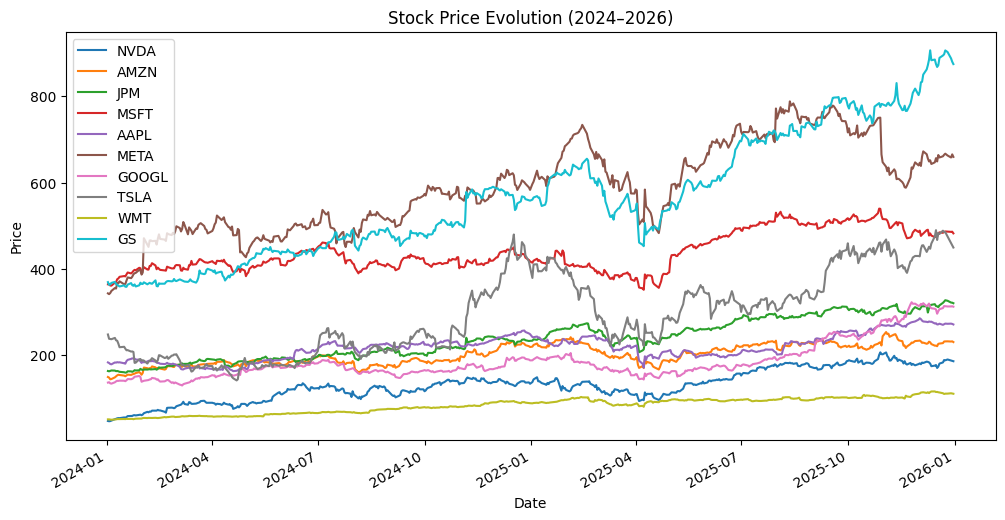

In [4]:
import matplotlib.pyplot as plt

prices.plot(figsize=(12,6))
plt.title("Stock Price Evolution (2024–2026)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [7]:
returns = prices.pct_change().dropna()

expected_returns = returns.mean()
cov_matrix = returns.cov()

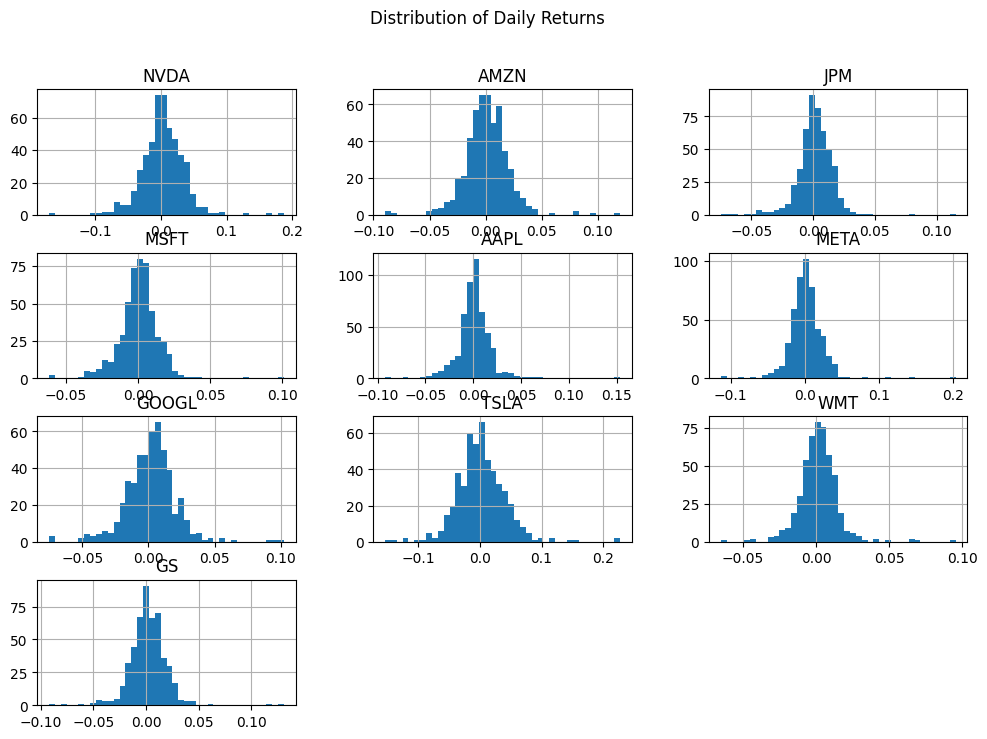

In [8]:
returns.hist(figsize=(12,8), bins=40)
plt.suptitle("Distribution of Daily Returns")
plt.show()

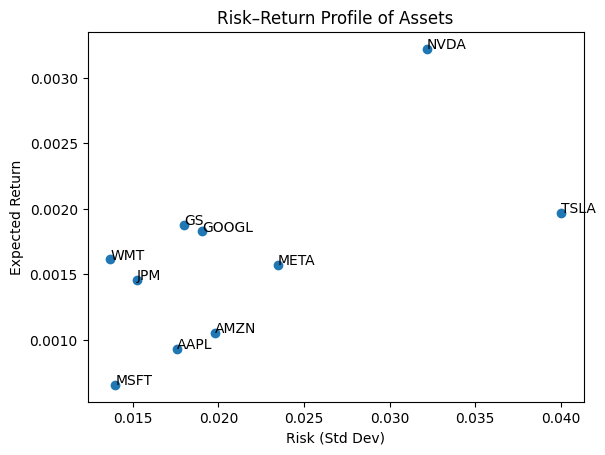

In [9]:
mean_returns = returns.mean()
risk = returns.std()

plt.scatter(risk, mean_returns)

for ticker in returns.columns:
    plt.annotate(ticker, (risk[ticker], mean_returns[ticker]))

plt.xlabel("Risk (Std Dev)")
plt.ylabel("Expected Return")
plt.title("Risk–Return Profile of Assets")
plt.show()

In [ ]:
pip install pulp
# lambdas = [0,10,20,50,100]

In [11]:
import pulp

def optimize_portfolio(expected_returns, K=5):

    tickers = expected_returns.index.tolist()

    model = pulp.LpProblem("Portfolio_Optimization",
                           pulp.LpMaximize)

    # Decision variables
    x = pulp.LpVariable.dicts("weight", tickers, 0, 1)
    y = pulp.LpVariable.dicts("select", tickers, 0, 1, cat="Binary")

    # Objective: maximize return
    model += pulp.lpSum(expected_returns[i] * x[i]
                        for i in tickers)

    # Budget constraint
    model += pulp.lpSum(x[i] for i in tickers) == 1

    # Cardinality constraint
    model += pulp.lpSum(y[i] for i in tickers) <= K

    # Linking constraint
    for i in tickers:
        model += x[i] <= y[i]

    # Solve
    model.solve()

    solution = {i: x[i].value() for i in tickers}
    selected = {i: y[i].value() for i in tickers}

    return solution, selected

In [12]:
weights, chosen = optimize_portfolio(expected_returns)

print("Optimal Weights:")
print(weights)

print("\nSelected Assets:")
print(chosen)

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/nushra/Desktop/om-assignment/.venv/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/_7/q2r69qyx5tqbg38t8m0wk5y00000gn/T/bb1e13d1e72e4c83af28bcd7c26cd46a-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/_7/q2r69qyx5tqbg38t8m0wk5y00000gn/T/bb1e13d1e72e4c83af28bcd7c26cd46a-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 17 COLUMNS
At line 88 RHS
At line 101 BOUNDS
At line 122 ENDATA
Problem MODEL has 12 rows, 20 columns and 40 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0.00322195 - 0.00 seconds
Cgl0004I processed model has 12 rows, 20 columns (10 integer (10 of which binary)) and 40 elements
Cbc0038I Initial state - 0 integers unsatisfied sum - 0
Cbc0038I Solution found of -0.00322195
Cbc0038I Relaxing continuous gi

In [13]:
import pulp
import numpy as np

def optimize_portfolio_MAD(returns, K=5, lam=50):

    tickers = returns.columns.tolist()
    T = len(returns)

    mean_returns = returns.mean()

    model = pulp.LpProblem("MAD_Portfolio", pulp.LpMaximize)

    # Decision variables
    x = pulp.LpVariable.dicts("weight", tickers, 0, 1)
    y = pulp.LpVariable.dicts("select", tickers, 0, 1, cat="Binary")

    # deviation variables
    z = pulp.LpVariable.dicts("deviation", range(T), 0)

    # ---------- OBJECTIVE ----------
    model += (
        pulp.lpSum(mean_returns[i]*x[i] for i in tickers)
        - lam*(1/T)*pulp.lpSum(z[t] for t in range(T))
    )

    # ---------- CONSTRAINTS ----------

    # Budget
    model += pulp.lpSum(x[i] for i in tickers) == 1

    # Cardinality
    model += pulp.lpSum(y[i] for i in tickers) == K

    # Linking constraints
    for i in tickers:
        model += x[i] <= y[i]
        model += x[i] >= 0.05*y[i]

    # MAD constraints
    for t in range(T):

        deviation = pulp.lpSum(
            (returns.iloc[t][i] - mean_returns[i]) * x[i]
            for i in tickers
        )

        model += z[t] >= deviation
        model += z[t] >= -deviation

    # Solve
    model.solve(pulp.PULP_CBC_CMD(msg=True))

    weights = {i: x[i].value() for i in tickers}
    selected = {i: y[i].value() for i in tickers}

    return weights, selected

In [14]:
weights, selected = optimize_portfolio_MAD(returns)

print(weights)
print(selected)

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/nushra/Desktop/om-assignment/.venv/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/_7/q2r69qyx5tqbg38t8m0wk5y00000gn/T/0705954ef00f4e8ca9681ce78c77f115-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/_7/q2r69qyx5tqbg38t8m0wk5y00000gn/T/0705954ef00f4e8ca9681ce78c77f115-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 1029 COLUMNS
At line 12643 RHS
At line 13668 BOUNDS
At line 13689 ENDATA
Problem MODEL has 1024 rows, 521 columns and 11082 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is -0.332692 - 0.02 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 21 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 3 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 1 strengthened rows, 0

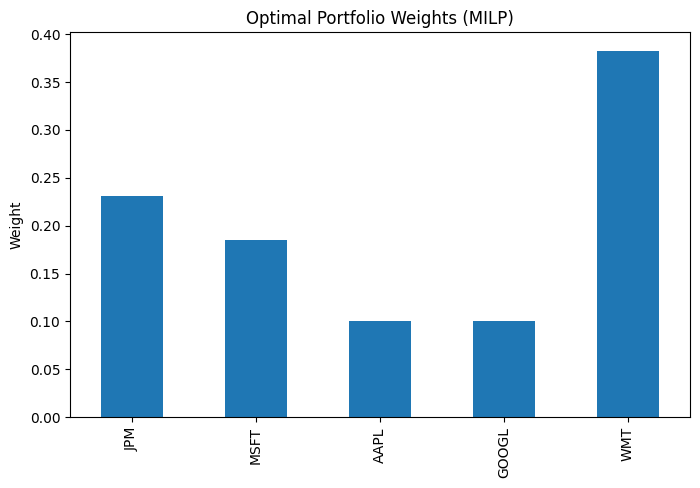

In [15]:
import pandas as pd

weights_series = pd.Series(weights)

weights_series[weights_series>0].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Optimal Portfolio Weights (MILP)")
plt.ylabel("Weight")
plt.show()

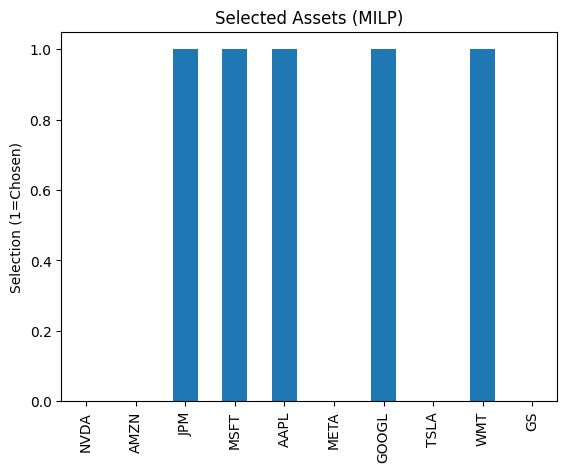

In [16]:
pd.Series(selected).plot(kind="bar")
plt.title("Selected Assets (MILP)")
plt.ylabel("Selection (1=Chosen)")
plt.show()